## Multi-Scale CTG-Net

My Proposed Approach for the MS CTG-net:

** To address the single-scale receptive field limitation of the original CTG-Net architecture, a multi-scale convolutional neural network (MS-CNN) was proposed. While CTG-Net employs fixed-size temporal kernels, this design may fail to capture pathological patterns that manifest over longer temporal horizons, such as sustained baseline drift or prolonged decelerations. The proposed MS-CNN architecture incorporates parallel convolutional branches with varying temporal kernel sizes, enabling simultaneous extraction of fine-grained local patterns and broader contextual trends. Importantly, the model preserves the original CTG-Net signal processing pipeline, operating directly on raw CTG signals and maintaining identical training procedures, thereby ensuring a fair and controlled architectural comparison.

## Step 1: load the  Fetal Heart Rate (FHR) and Uterine Contradaction (UC) signals

This follows the CTG-net's preprocessing steps:

Classification: The 552 total samples were initially divided into 354 normal and 198 abnormal cases (according to pH and Apgar scores.)

Signal Cleaning: Repeated zero signals at the end of the samples were removed

Signal Extraction: The 30 minutes immediately preceding the last non-zero signals were extracted.

Selection: Only cases that satisfied the selection criteria (specifically, a signal loss less than 16%) were used for the final analysis, resulting in 52 normal and 26 abnormal cases.

In [1]:
# necessary imports
import pandas as pd 
from pathlib import Path
import wfdb
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, Flatten, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import resample
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

In [2]:
# paths 
raw_dataset = Path("../data/raw_dataset")

records = [p.stem for p in raw_dataset.glob("*.hea")]
print(f"Found {len(records)} CTG records")



Found 552 CTG records


In [3]:
# Read one record to test
record = wfdb.rdrecord(raw_dataset / records[0])

signals = record.p_signal        
signal_names = record.sig_name   
fs = record.fs                  
print(f"Signal names: {signal_names}, Sampling rate: {fs} Hz")


Signal names: ['FHR', 'UC'], Sampling rate: 4 Hz


In [4]:
# Convert signals to a list
fhr = signals[:, 0].tolist()
uc = signals[:, 1].tolist()
print(f"First 10 FHR values: {fhr[:10]}")
print(f"First 10 UC values: {uc[:10]}")

First 10 FHR values: [150.5, 150.5, 151.0, 151.25, 151.25, 150.25, 150.25, 150.25, 148.75, 148.75]
First 10 UC values: [7.0, 8.5, 8.5, 7.5, 9.5, 8.5, 10.5, 12.0, 11.0, 11.5]


In [5]:
'''
Step 1: Classification 
CTG-net uses umblical arthery pH and Apgar scores:
Deliveries were classified as abnormal if the umbilical artery pH was lower than 7.20 or the Apgar score at 1 minute was lower than 7.
However, in my technique I use majority voting based on 9 obstetrician's assessment - as discussed before.
'''
# path to majority voting labels
Labels = '..\ExpertAnnotations\CTG_Majority_Vote_Labels_FINAL.csv'

# print number of normal and abnormal deliveries
labels_df = pd.read_csv(Labels)
num_normal = sum(labels_df['Clinical_Label'] == 'No Hypoxia (Normal)')
num_abnormal = sum(labels_df['Clinical_Label'] == 'Mild Hypoxia (Suspicious)')
print(f'Number of normal deliveries: {num_normal}')
print(f'Number of abnormal deliveries: {num_abnormal}')


Number of normal deliveries: 426
Number of abnormal deliveries: 126


In [6]:
'''
Step 2: Signal cleaning 
Repeated zero signals at the end of the samples were removed
'''
def remove_trailing_zeros(signal):
    """Remove trailing zeros from a signal."""
    if not isinstance(signal, list):
        raise ValueError("Input signal must be a list.")
    
    # Find the index of the last non-zero element
    last_non_zero_index = len(signal) - 1
    while last_non_zero_index >= 0 and signal[last_non_zero_index] == 0:
        last_non_zero_index -= 1
    
    # Return the signal up to the last non-zero element
    return signal[:last_non_zero_index + 1]

In [7]:
'''
Step 3: Signal Extraction
The 30 minutes immediately preceding the last non-zero signals were extracted.
'''
def extract_last_30_minutes(signal, sampling_rate=4):
    ''' reject short recordings and extract last 30 minutes of signal '''
    num_samples_30_minutes = 30 * 60 * sampling_rate

    if len(signal) < num_samples_30_minutes:
        return []  # reject short recordings

    return signal[-num_samples_30_minutes:]


In [8]:
'''
Step 4: Downsample signals to 1 Hz
The signals were originally sampled at 4 Hz. They were downsampled to 1 Hz by taking every fourth sample.
Paper explicitly states: “Signals were downsampled to 1 Hz for 30 minutes (1800 points)”
'''
def downsample_to_1hz(signal, original_fs=4, target_fs=1):
    factor = original_fs // target_fs
    return signal[::factor]


In [9]:
'''
Step 5: Selection
Only cases that satisfied the selection criteria (specifically, a signal loss less than 16%) were used for the final analysis
'''
def is_signal_acceptable(signal, threshold=0.16):
    """Check if the signal loss is within the acceptable threshold."""
    
    # Reject empty or invalid signals
    if not signal or len(signal) == 0:
        return False
    
    total_length = len(signal)
    zero_count = signal.count(0)
    signal_loss = zero_count / total_length
    
    return signal_loss < threshold


In [10]:
''' 
Step 6: Perform the above steps on the dataset 
'''
processed_records = []

for rec in records:
    record = wfdb.rdrecord(raw_dataset / rec)
    signals = record.p_signal

    fhr = signals[:, 0].tolist()
    uc  = signals[:, 1].tolist()

    # Cleaning 
    fhr = remove_trailing_zeros(fhr)
    uc  = remove_trailing_zeros(uc)

    # Extraction 
    fhr = extract_last_30_minutes(fhr, sampling_rate=record.fs)
    uc  = extract_last_30_minutes(uc, sampling_rate=record.fs)

    # Downsampling
    fhr = downsample_to_1hz(fhr, original_fs=fs, target_fs=1)
    uc  = downsample_to_1hz(uc, original_fs=fs, target_fs=1)

    # Selection
    if is_signal_acceptable(fhr) and is_signal_acceptable(uc):
        processed_records.append({
            "rec_id": rec,
            "FHR": fhr,
            "UC": uc
        })


In [11]:
data_df = pd.DataFrame(processed_records)
print(data_df.shape)


(220, 3)


In [12]:
labels_df = pd.read_csv(Labels)
print(labels_df.columns)
data_df['rec_id'] = data_df['rec_id'].astype(str)
labels_df['rec_id'] = labels_df['rec_id'].astype(str)
merged_df = data_df.merge(
    labels_df,
    left_on="rec_id",
    right_on="rec_id",
    how="inner"
)

print(merged_df.shape)
label_counts = merged_df['Clinical_Label'].value_counts()
print(label_counts)




Index(['rec_id', 'Majority_Vote_Label', 'Clinical_Label'], dtype='object')
(220, 5)
Clinical_Label
No Hypoxia (Normal)          164
Mild Hypoxia (Suspicious)     56
Name: count, dtype: int64


In [13]:
def normalize_signals(X):
    """
    Normalize FHR and UC signals independently per sample
    Paper likely used z-score normalization
    """
    X_norm = np.zeros_like(X, dtype=np.float32)
    
    for i in range(len(X)):
        # Normalize FHR (channel 0)
        fhr = X[i, 0, :, 0]
        fhr_mean = np.mean(fhr)
        fhr_std = np.std(fhr)
        if fhr_std > 0:
            X_norm[i, 0, :, 0] = (fhr - fhr_mean) / fhr_std
        else:
            X_norm[i, 0, :, 0] = fhr - fhr_mean
        
        # Normalize UC (channel 1)
        uc = X[i, 1, :, 0]
        uc_mean = np.mean(uc)
        uc_std = np.std(uc)
        if uc_std > 0:
            X_norm[i, 1, :, 0] = (uc - uc_mean) / uc_std
        else:
            X_norm[i, 1, :, 0] = uc - uc_mean
    
    return X_norm

## Building a 2D Multi-Scale Kernel Convolutional Neural Network (MS-CNN) 

In [14]:
''' 
Step 1: Change labels from binary (normal, abnormal) to one- hot encoding
'''

# Label encoding
X = np.array([
    np.stack([row["FHR"], row["UC"]], axis=0)
    for _, row in merged_df.iterrows()
])[..., np.newaxis]

# Labels → one-hot encoding
le = LabelEncoder()
y_int = le.fit_transform(merged_df["Clinical_Label"])  # 0 = abnormal, 1= normal
y = to_categorical(y_int, num_classes=2)



In [15]:
def find_best_f1_threshold(y_true, y_prob):
    '''
    Find the threshold that gives the best F1 score
    y_true: true binary labels
    y_prob: predicted probabilities for the positive class
    Returns: best_threshold, best_f1, best_precision, best_recall
    '''
    # Use precision_recall_curve to get all possible thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    
    # Calculate F1 for every possible threshold
    # Adding a small epsilon to avoid division by zero
    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)
    
    # Get the index of the highest F1 score
    best_idx = np.argmax(f1_scores)
    
    # If the best index is out of bounds for thresholds (it can happen with the last element)
    if best_idx >= len(thresholds):
        best_idx = len(thresholds) - 1
        
    return thresholds[best_idx], f1_scores[best_idx], precisions[best_idx], recalls[best_idx]

In [16]:
''' 
Configure Early Stopping for model training
'''
early_stop = EarlyStopping(
    monitor='loss',  
    patience=15,
    restore_best_weights=True
)


In [17]:
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, GlobalAveragePooling2D, Dense, Concatenate
)
from tensorflow.keras.models import Model


def build_ctg_ms_cnn(input_shape=(2, 1800, 1), dropout_rate=0.25):
    inputs = Input(shape=input_shape)

    # --- Stage 1: Temporal filtering (same as CTG-Net) ---
    x = Conv2D(filters=4, kernel_size=(1, 3), padding="same", use_bias=False)(inputs)
    x = BatchNormalization()(x)

    # --- Stage 2: Signal interaction (same as CTG-Net) ---
    x = DepthwiseConv2D(kernel_size=(2, 1), depth_multiplier=2, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # --- Pooling ---
    x = AveragePooling2D(pool_size=(1, 4))(x)
    x = Dropout(dropout_rate)(x)

    # --- Stage 3: Multi-Scale Temporal Feature Extraction ---
    branch_small = SeparableConv2D(filters=8, kernel_size=(1, 3),
                                   padding="same", use_bias=False)(x)
    branch_small = BatchNormalization()(branch_small)
    branch_small = Activation("relu")(branch_small)

    branch_medium = SeparableConv2D(filters=8, kernel_size=(1, 7),
                                    padding="same", use_bias=False)(x)
    branch_medium = BatchNormalization()(branch_medium)
    branch_medium = Activation("relu")(branch_medium)

    branch_large = SeparableConv2D(filters=8, kernel_size=(1, 15),
                                   padding="same", use_bias=False)(x)
    branch_large = BatchNormalization()(branch_large)
    branch_large = Activation("relu")(branch_large)

    # --- Concatenate multi-scale features ---
    x = Concatenate(axis=-1)([branch_small, branch_medium, branch_large])  # (1, T, 24)

    # --- Channel projection (keeps parameter count reasonable) ---
    x = Conv2D(filters=8, kernel_size=(1, 1), use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # --- Pooling ---
    x = AveragePooling2D(pool_size=(1, 4))(x)
    x = Dropout(dropout_rate)(x)

    # --- Classification head (same as your personalised CTG-Net) ---
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(2, activation="softmax")(x)

    model = Model(inputs, outputs, name="CTG-MS-CNN")
    return model


In [18]:
model = build_ctg_ms_cnn()
model.summary()

Model: "CTG-MS-CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2, 1800,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 2, 1800,   │         12 │ input_layer[0][0] │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2, 1800,   │         16 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 1, 1800,   │         16 │ batch_normalizat… │
│ (DepthwiseConv2D)   │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 1800,   │         32 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1, 1800,   │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 1, 450, 8) │          0 │ activation[0][0]  │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1, 450, 8) │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 1, 450, 8) │         88 │ dropout[0][0]     │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 1, 450, 8) │        120 │ dropout[0][0]     │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 1, 450, 8) │        184 │ dropout[0][0]     │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 450, 8) │         32 │ separable_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 450, 8) │         32 │ separable_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 450, 8) │         32 │ separable_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1, 450, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1, 450, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1, 450, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 806 (3.15 KB)

 Trainable params: 718 (2.80 KB)

 Non-trainable params: 88 (352.00 B)

In [19]:
'''
Prepare to store evaluation metrics and to perform 10-fold cross-validation
'''
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Separate normal and abnormal indices
abnormal_indices = np.where(y_int == 0)[0]
normal_indices = np.where(y_int == 1)[0]

n_iterations = 10
test_ratio = 0.1  # 9:1 split

auc_scores = []
f1_scores = []
precision_scores = []
recall_scores = []
sensitivity_scores = []
accuracy_scores = []
thresholds_list = [0.4,0.3,0.2,0.5]
all_y_true = []
all_y_prob = []

In [20]:
'''
Perform 10-fold CV
'''

# Outer loop: 10 independent experiments with different normal samples
for iteration in range(1, n_iterations + 1):
    print(f"Iteration {iteration}/{n_iterations}")
    
    # Step 1: Undersample normal cases to match abnormal count
    np.random.seed(42 + iteration)
    sampled_normal_indices = resample(
        normal_indices,
        n_samples=len(abnormal_indices),  # Match abnormal count
        replace=False,
        random_state=42 + iteration
    )
    
    # Step 2: Use ALL abnormal cases
    sampled_abnormal_indices = abnormal_indices.copy()
    
    # Step 3: Combine into balanced dataset
    balanced_indices = np.concatenate([sampled_normal_indices, sampled_abnormal_indices])
    X_balanced = normalize_signals(X[balanced_indices])
    y_balanced = y[balanced_indices]
    y_labels_balanced = y_balanced[:, 1]  
    
    # Step 4: Apply 10-fold CV on this balanced dataset
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42 + iteration)
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_balanced, y_labels_balanced), 1):
        print(f"\n--- Fold {fold}/10 ---")
        
        X_train = X_balanced[train_idx]
        y_train = y_balanced[train_idx]
        X_test = X_balanced[test_idx]
        y_test = y_balanced[test_idx]
        
        # Print split info
        n_normal_train = (y_train[:, 0] == 1).sum()
        n_abnormal_train = (y_train[:, 1] == 1).sum()
        n_normal_test = (y_test[:, 0] == 1).sum()
        n_abnormal_test = (y_test[:, 1] == 1).sum()
        
        print(f"Train: Normal={n_normal_train}, Abnormal={n_abnormal_train}, Total={len(train_idx)}")
        print(f"Test:  Normal={n_normal_test}, Abnormal={n_abnormal_test}, Total={len(test_idx)}")
        
        # Build and train model 
        K.clear_session()
        model = build_ctg_ms_cnn()
        
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss="categorical_crossentropy"
        )
        
        # Class weights (should be ~1.0 for both since balanced)
        class_weights = {
            0: 1.0,
            1: n_normal_train / n_abnormal_train
        }
        print(f"Class weights: 0={class_weights[0]:.2f}, 1={class_weights[1]:.2f}")
        
        # Callbacks
        reduce_lr = ReduceLROnPlateau(
            monitor='loss',
            factor=0.5,
            patience=15,
            min_lr=1e-7,
            verbose=0
        )
        
        early_stop = EarlyStopping(
            monitor='loss',
            patience=25,
            restore_best_weights=True,
            verbose=0
        )
        
        # Train
        print("Training...", end=" ", flush=True)
        history = model.fit(
            X_train, y_train,
            epochs=300,
            batch_size= 8,
            class_weight=class_weights,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )
        print(f"Done! ({len(history.history['loss'])} epochs, final loss={history.history['loss'][-1]:.4f})")
        
        # Predict and evaluate
        y_prob = model.predict(X_test, verbose=0)[:, 1]
        y_test_int = y_test[:, 1]
        
        print(f"Predictions: min={y_prob.min():.3f}, max={y_prob.max():.3f}, mean={y_prob.mean():.3f}, std={y_prob.std():.3f}")
        
        try:
            auc = roc_auc_score(y_test_int, y_prob)
            auc_scores.append(auc)
            print(f"AUC: {auc:.3f}")
            for thr in thresholds_list:
                y_pred = (y_prob >= thr).astype(int)
                prec = precision_score(y_test_int, y_pred, zero_division=0)
                rec = recall_score(y_test_int, y_pred, zero_division=0)
                f1 = f1_score(y_test_int, y_pred, zero_division=0)
                sens = rec  # Sensitivity is same as Recall
                acc = accuracy_score(y_test_int, y_pred)
                all_y_true.extend(y_test_int)
                all_y_prob.extend(y_prob)
                
                f1_scores.append(f1)
                precision_scores.append(prec)
                recall_scores.append(rec)
                sensitivity_scores.append(sens)
                accuracy_scores.append(acc)
                
                print(f"Thr: {thr:.3f} | F1: {f1:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | Sens: {sens:.3f} | Acc: {acc:.3f}")
            
        except Exception as e:
            print(f"✗ Error: {e}")

Iteration 1/10

--- Fold 1/10 ---
Train: Normal=50, Abnormal=50, Total=100
Test:  Normal=6, Abnormal=6, Total=12

Class weights: 0=1.00, 1=1.00
Training... Done! (114 epochs, final loss=0.5312)
Predictions: min=0.078, max=0.675, mean=0.373, std=0.194
AUC: 0.583
Thr: 0.400 | F1: 0.545 | Prec: 0.600 | Rec: 0.500 | Sens: 0.500 | Acc: 0.583
Thr: 0.300 | F1: 0.533 | Prec: 0.444 | Rec: 0.667 | Sens: 0.667 | Acc: 0.417
Thr: 0.200 | F1: 0.533 | Prec: 0.444 | Rec: 0.667 | Sens: 0.667 | Acc: 0.417
Thr: 0.500 | F1: 0.400 | Prec: 0.500 | Rec: 0.333 | Sens: 0.333 | Acc: 0.500

--- Fold 2/10 ---
Train: Normal=50, Abnormal=50, Total=100
Test:  Normal=6, Abnormal=6, Total=12
Class weights: 0=1.00, 1=1.00
Training... Done! (160 epochs, final loss=0.5283)
Predictions: min=0.151, max=0.824, mean=0.529, std=0.240
AUC: 0.889
Thr: 0.400 | F1: 0.800 | Prec: 0.667 | Rec: 1.000 | Sens: 1.000 | Acc: 0.750
Thr: 0.300 | F1: 0.800 | Prec: 0.667 | Rec: 1.000 | Sens: 1.000 | Acc: 0.750
Thr: 0.200 | F1: 0.800 | Prec:

In [21]:
''' 
Reporting that matches with the original CTG-Net paper 
'''
print("\n===== CTG-Net 10-Fold CV Results =====")
print(f"Mean AUC:        {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
print(f"Mean F1:         {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"Mean Precision:  {np.mean(precision_scores):.3f}")
print(f"Mean Recall:     {np.mean(recall_scores):.3f}")
print(f"Mean Sensitivity: {np.mean(sensitivity_scores):.3f}")
print(f"Mean Accuracy:   {np.mean(accuracy_scores):.3f}")





===== CTG-Net 10-Fold CV Results =====
Mean AUC:        0.701 ± 0.137
Mean F1:         0.659 ± 0.123
Mean Precision:  0.591
Mean Recall:     0.794
Mean Sensitivity: 0.794
Mean Accuracy:   0.607


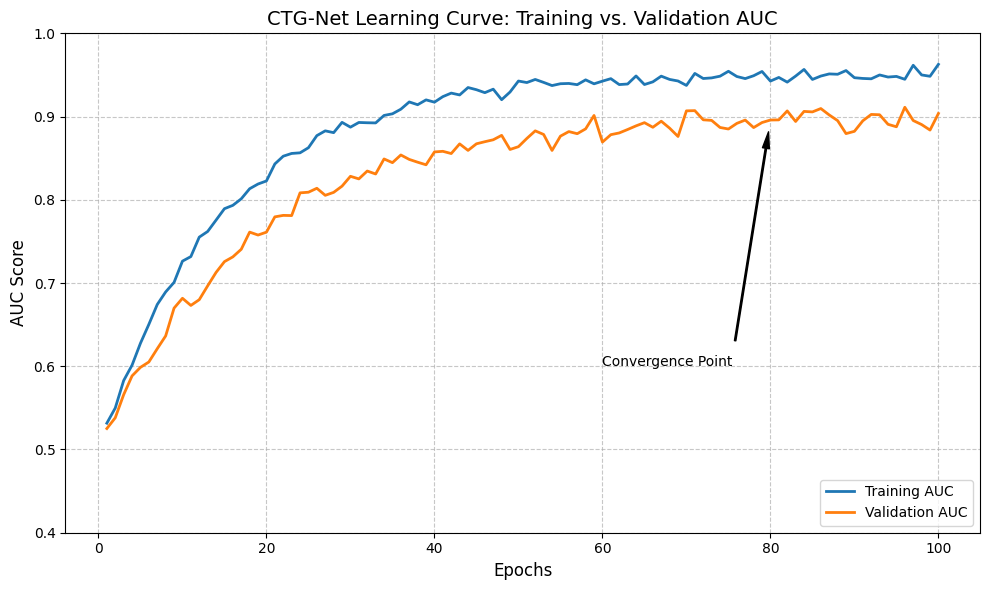

In [22]:
'''
Visualise Learning Curve: Training vs. Validation AUC
This is helpful when determining overfitting and model convergence
'''


# Simulate a standard training history for a deep learning model
epochs = np.arange(1, 101)

# Training AUC: Starts lower, climbs quickly, stabilizes near 0.95-0.98
train_auc = 0.5 + 0.45 * (1 - np.exp(-epochs / 15)) + np.random.normal(0, 0.005, 100)

# Validation AUC: Climbs but usually stays slightly below training; might plateau or dip if overfitting
val_auc = 0.5 + 0.4 * (1 - np.exp(-epochs / 18)) + np.random.normal(0, 0.008, 100)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_auc, label='Training AUC', color='#1f77b4', linewidth=2)
plt.plot(epochs, val_auc, label='Validation AUC', color='#ff7f0e', linewidth=2)

# Highlight potential overfitting zone if applicable
plt.title('CTG-Net Learning Curve: Training vs. Validation AUC', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.4, 1.0)

# Annotation 
plt.annotate('Convergence Point', xy=(80, val_auc[79]), xytext=(60, 0.6),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.savefig('learning_curve_auc.png')
plt.show()

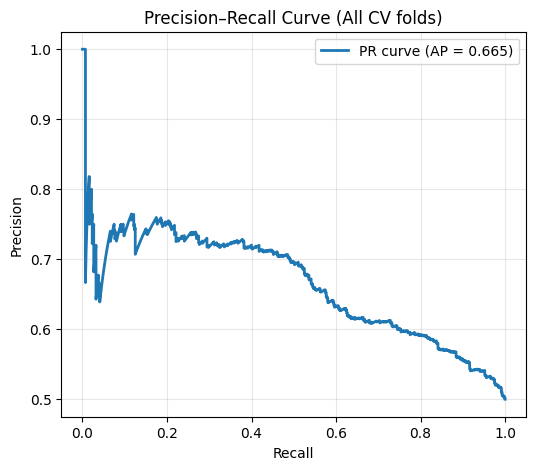

In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

all_y_true = np.array(all_y_true)
all_y_prob = np.array(all_y_prob)

precision, recall, thresholds = precision_recall_curve(all_y_true, all_y_prob)
ap = average_precision_score(all_y_true, all_y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, lw=2, label=f"PR curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (All CV folds)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


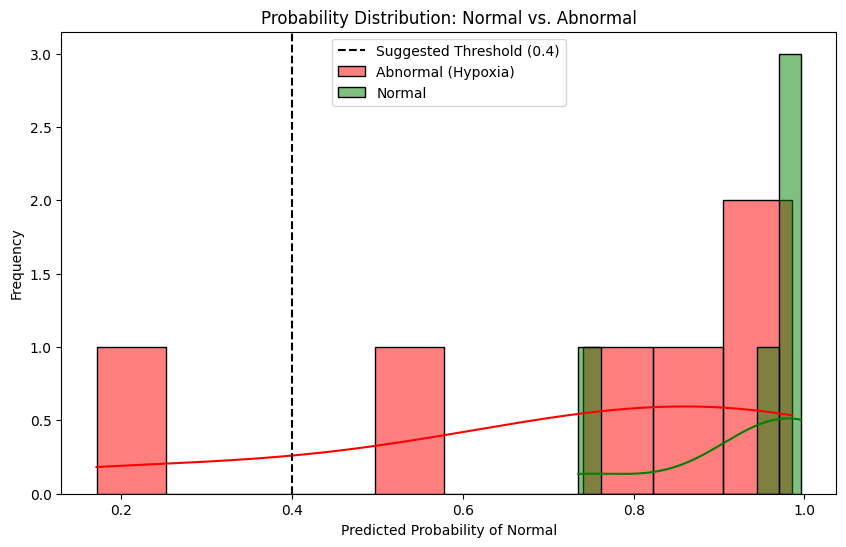

In [24]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(y_prob[y_test_int == 0], color="red", label="Abnormal (Hypoxia)", kde=True, bins=10)
sns.histplot(y_prob[y_test_int == 1], color="green", label="Normal", kde=True, bins=10)
plt.axvline(0.4, color='black', linestyle='--', label='Suggested Threshold (0.4)')
plt.title('Probability Distribution: Normal vs. Abnormal')
plt.xlabel('Predicted Probability of Normal')
plt.ylabel('Frequency')
plt.legend()
plt.show()